# Fontana Emanuele, Edge Detection #

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

Loading photo

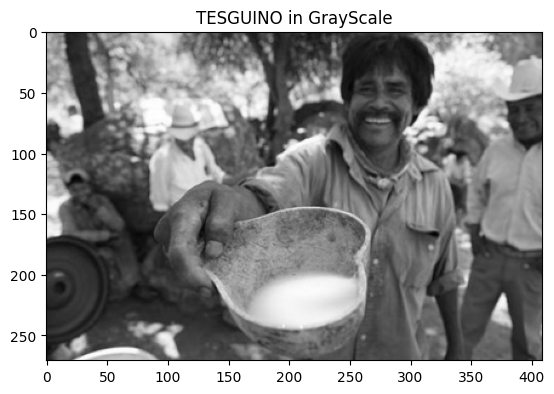

In [5]:
img=cv2.imread('Tesguino.png')
original = img.copy()
img=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img, cmap='gray',vmin=0, vmax=255)
plt.title("TESGUINO in GrayScale")
plt.show()


## Let's apply the Prwitt and Sobel filters to the image ##

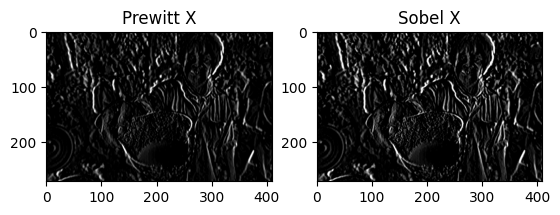

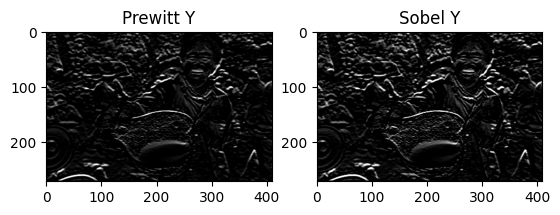

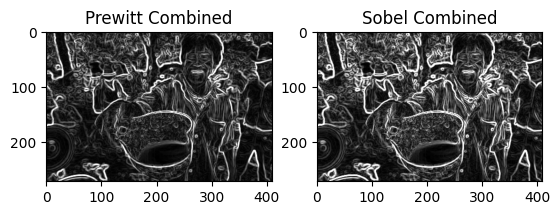

In [6]:
# Prewitt definition
prewitt_x = np.array([[-1, 0, 1], 
                       [-1, 0, 1], 
                       [-1, 0, 1]])

prewitt_y = np.array([[-1, -1, -1], 
                       [ 0,  0,  0], 
                       [ 1,  1,  1]])

# Applying Prewitt filter
prewittx = cv2.filter2D(img, cv2.CV_64F, prewitt_x)
prewitty = cv2.filter2D(img, cv2.CV_64F, prewitt_y)
prewitt_magnitude = cv2.magnitude(prewittx, prewitty)

sobelx = cv2.Sobel(img,cv2.CV_64F, dx = 1, dy = 0,ksize=3)
sobely = cv2.Sobel(img,cv2.CV_64F, dx = 0, dy = 1,ksize=3)
sobel_magnitude = cv2.magnitude(sobelx, sobely)


plt.subplot(1, 2, 1)
plt.imshow(prewittx, cmap='gray',vmin=0, vmax=255)
plt.title("Prewitt X")
plt.subplot(1, 2, 2)
plt.imshow(sobelx, cmap='gray',vmin=0, vmax=255)
plt.title("Sobel X")
plt.show()

plt.subplot(1, 2, 1)
plt.imshow(prewitty, cmap='gray',vmin=0, vmax=255)
plt.title("Prewitt Y")
plt.subplot(1, 2, 2)
plt.imshow(sobely, cmap='gray',vmin=0, vmax=255)
plt.title("Sobel Y")
plt.show()

plt.subplot(1, 2, 1)
plt.imshow(prewitt_magnitude, cmap='gray',vmin=0, vmax=255)
plt.title("Prewitt Combined")
plt.subplot(1, 2, 2)
plt.imshow(sobel_magnitude, cmap='gray',vmin=0, vmax=255)
plt.title("Sobel Combined")
plt.show()


# Aplly Otsu Method on both magnitude images #

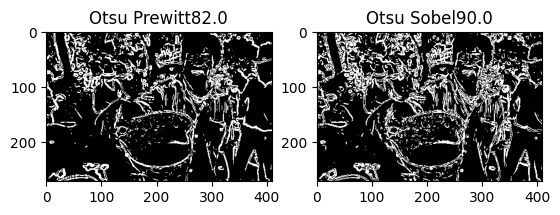

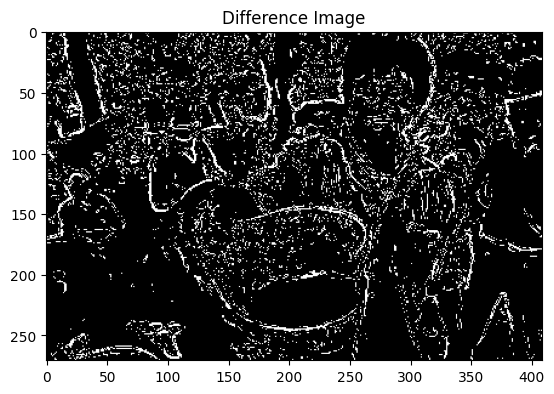

In [7]:
#transform to uint8
prewitt_magnitude = prewitt_magnitude.astype(np.uint8)
sobel_magnitude = sobel_magnitude.astype(np.uint8)
# Otsu's thresholding
otsuPrewittThresh, otsuPrewitt = cv2.threshold(prewitt_magnitude, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
otsuSobelThresh, otsuSobel = cv2.threshold(sobel_magnitude, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.subplot(1, 2, 1)
plt.imshow(otsuPrewitt, cmap='gray',vmin=0, vmax=255)
plt.title("Otsu Prewitt" + str(otsuPrewittThresh))
plt.subplot(1, 2, 2)
plt.imshow(otsuSobel, cmap='gray',vmin=0, vmax=255)
plt.title("Otsu Sobel" + str(otsuSobelThresh))
plt.show()


differenceImage = cv2.absdiff(otsuPrewitt, otsuSobel)
plt.imshow(differenceImage, cmap='gray',vmin=0, vmax=255)
plt.title("Difference Image")
plt.show()

# Canny edge detector #

Let's try to apply different thresholds to the Canny edge detector and see how it works

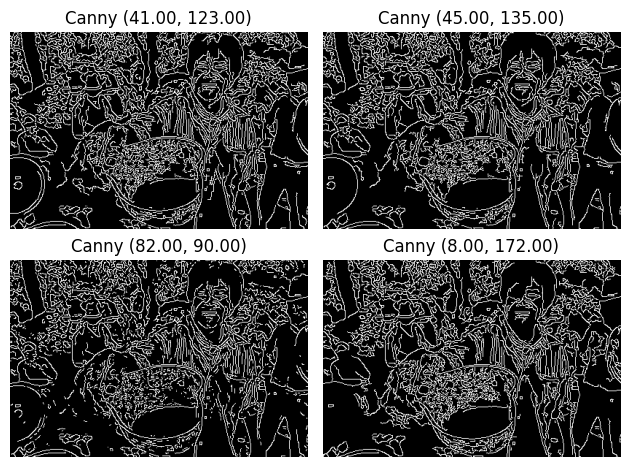

In [8]:
thresholds=[(otsuPrewittThresh*0.5, otsuPrewittThresh*1.5), (otsuSobelThresh*0.5, otsuSobelThresh*1.5),(min(otsuPrewittThresh, otsuSobelThresh), max(otsuPrewittThresh, otsuSobelThresh)),(abs(otsuPrewittThresh-otsuSobelThresh), abs(otsuPrewittThresh+otsuSobelThresh))]
for i, (low, high) in enumerate(thresholds):
    canny = cv2.Canny(img, low, high)
    plt.subplot(2, 2, i + 1)
    plt.imshow(canny, cmap='gray',vmin=0, vmax=255)
    plt.title(f"Canny ({low:.2f}, {high:.2f})")
    plt.axis('off')
plt.tight_layout()
plt.show()

In generl we can notice that with the Canny edge detector edges are more precise and well defined. The edges are also more continuous and less noisy than the ones obtained with the Sobel and Prewitt filters.